# End-to-End Retail Analytics: Predictive Churn Modeling & RFM Clustering 

In [22]:
suppressWarnings(
suppressPackageStartupMessages({
    library(tidyverse)   # cleaning and plotting
    library(mice)        # missing data imputation
    library(tidymodels)  # ML/Churn prediction
    library(infer)       # hypothesis testing
    library(tidyquant)   # monetary/financial analysis
    library(lubridate)   # InvoiceDate timestamps
    library(patchwork)   # stacking segmentation and churn plots together
    library(cluster)     # K-Means segmentation
    library(factoextra)  # visualize clusters
    library(writexl)     
    library(janitor)
    library(naniar)}))  

### Data Preprocessing & Feature Engineering

In [23]:
df <- read_csv("retail_dataset.csv") %>%
    clean_names()
head(df)

Rows: 1067371 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): Invoice, StockCode, Description, Country
dbl  (3): Quantity, Price, Customer ID
dttm (1): InvoiceDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom


In [24]:
summary(df)

      invoice            stock_code         description     
 Length   :1067371   Length   :1067371   Length   :1067371  
 N.unique :  53628   N.unique :   5304   N.unique :   5655  
 N.blank  :      0   N.blank  :      0   N.blank  :      0  
 Min.nchar:      6   Min.nchar:      1   Min.nchar:      1  
 Max.nchar:      7   Max.nchar:     12   Max.nchar:     35  
                                         NAs      :   4382  
                                                            
    quantity           invoice_date                     price           
 Min.   :-80995.000   Min.   :2009-12-01 07:45:00   Min.   :-53594.360  
 1st Qu.:     1.000   1st Qu.:2010-07-09 09:46:00   1st Qu.:     1.250  
 Median :     3.000   Median :2010-12-07 15:28:00   Median :     2.100  
 Mean   :     9.939   Mean   :2011-01-02 21:13:55   Mean   :     4.649  
 3rd Qu.:    10.000   3rd Qu.:2011-07-22 10:23:00   3rd Qu.:     4.150  
 Max.   : 80995.000   Max.   :2011-12-09 12:50:00   Max.   : 38970.000  
 

In [19]:
# Finding % of missing values across columns
df %>% summarise(across(everything(), ~ mean(is.na(.)) * 100))

invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0.4105414,0,0,0,22.76687,0


**Note:** Roughly 23% of the values from "customer_id" are missing which is concerning. However the data doesnt state the cause of these customer_ids missing, good guessing of why the data is missing include guest checkout features, system errors or potentially even POS cash transactions. Since the goal is to run a RFM clustering and churn modelling, these missing values are excluded from the analysis. Also a very negligible amount of values are missing from the "description" column (~0.5%) maybe due to random sysetm errors. 

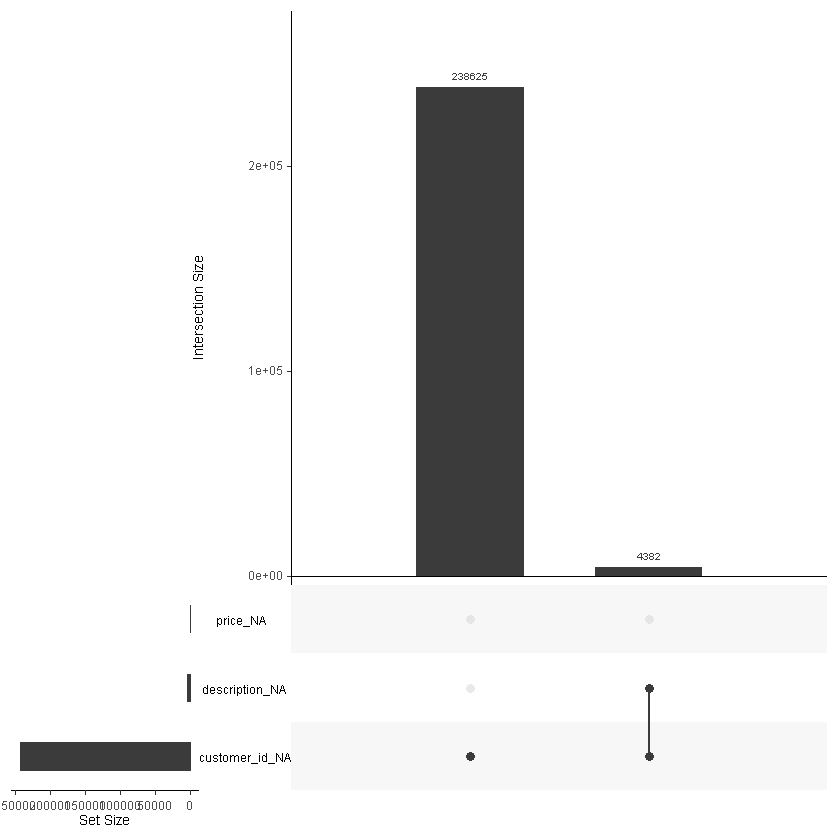

In [27]:
# Looking for any relation between the missing values of "customer_id" and "description"
suppressWarnings(gg_miss_upset(df, nsets = 3))

**Conclusion:** The plot above shows that all values missing a descrpition are also missing a customer_id (100% correlation between missing description and missing customer_id). This confirms that the descrpition missing values are not random and are due to a system fault.

In [30]:
# Removing the NA values from the dataset 
df_cleaned <- df %>%
    filter(!is.na(customer_id))

In [31]:
# Counting the number of orders per customer
all_orders <- df_cleaned %>%
    group_by(customer_id) %>%
    summarize(total_orders = n_distinct(invoice))     # total orders include cancelled orders
head(all_orders)

customer_id,total_orders
<dbl>,<int>
12346,17
12347,8
12348,5
12349,5
12350,1
12351,1


In [32]:
# Counting the number of cancelled orders per customer
cancellations <- df_cleaned %>%
    filter(str_detect(invoice, "(?i)^c")) %>%
    group_by(customer_id) %>%
    summarize(canceled_orders = n_distinct(invoice))
head(cancellations)

customer_id,canceled_orders
<dbl>,<int>
12346,5
12349,1
12352,3
12359,4
12360,1
12362,3


In [33]:
customer_cancellations <- all_orders %>%
    left_join(cancellations, by = "customer_id") %>%
    mutate(canceled_orders = replace_na(canceled_orders, 0),
    cancellation_rate = canceled_orders / total_orders)
head(customer_cancellations)

customer_id,total_orders,canceled_orders,cancellation_rate
<dbl>,<int>,<int>,<dbl>
12346,17,5,0.2941176
12347,8,0,0.0000000
12348,5,0,0.0000000
12349,5,1,0.2000000
12350,1,0,0.0000000
12351,1,0,0.0000000
